# Notebook para inferencia 

el presente archivo permite descargar los modelos guardados en weigth & bias generados mediante el notebook [TF_entrenamiento_agregados_v7.ipynb](./entrenamiento_de_modelos/TF_entrenamiento_agregados_v7) y cargar un directorio con muestras de sensores de aceleracion para realizar una prediccion de posibles fallas en los elementos rodantes.


## Definiciones y dependencias


In [2]:
def cargar_archivo(ruta, sep='\t'):
  """
    Carga un archivo CSV y asigna nombre a las columnas.

    Esta función lee un archivo CSV desde la ruta proporcionada, asumiendo que
    los valores están separados por tabulaciones ('\t'). Luego, asigna nombres
    genéricos a las columnas del dataset en el formato 'Canal 1', 'Canal 2', ...,
    según la cantidad de columnas que tenga el archivo.

    Args:
        ruta (str): La ruta completa al archivo CSV que se desea cargar.
        sep (str, optional): El separador utilizado en el archivo CSV. Por defecto es '\t'.

    Returns:
        pd.DataFrame: Un DataFrame de pandas con los datos cargados, con nombres
        de columnas asignados como 'Canal 1', 'Canal 2', etc.

    Example:
        >>> cargar_archivo('ruta/al/archivo.csv')
        <DataFrame con las columnas renombradas>
  """
  dataset = pd.read_csv(ruta, sep=sep)
  cantidad_columnas = len(dataset.columns)
  dataset.columns = [f"Canal {i}" for i in range(1, cantidad_columnas + 1)]
  return dataset

In [3]:
# Frecuencia de muestreo para el IMS Dataset
FS_IMS = 20000 

In [4]:
import numpy as np
from scipy.stats import skew, kurtosis, entropy

# 1. Amplitud máxima (Peak Amplitude)
def peak_amplitude(x):
    if x.size == 0:
        return 0

    x_max = np.max(x)
    x_min = np.min(x)

    return 0.5 * (x_max - x_min)
    
# 2. Amplitud media (Mean Amplitude)
def mean_amplitude(x):
    return np.mean(x)

# 3. Amplitud cuadrática media (RMS)
def rms_amplitude(x):
    return np.sqrt(np.mean(np.square(x)))
    

# 4. Amplitud pico a pico (Peak-to-Peak Amplitude)
def peak_to_peak_amplitude(x):
    return np.max(x) - np.min(x)

# 5. Factor de cresta (Crest Factor)
def crest_factor(x):
    return peak_amplitude(x) / rms_amplitude(x)

# 6. Varianza
def variance(x):
    return np.var(x)

# 7. Desviación estándar
def standard_deviation(x):
    return np.std(x)

# 8. Error estándar
def standard_error(x):
    return np.std(x) / np.sqrt(len(x))

# 9. Cruce por cero (Zero Crossing)
def zero_crossings(x, threshold=0):
    """
    Calcula el número de cruces por cero de una serie de tiempo.

    Args:
        x (list or numpy.ndarray): La señal de entrada.
        threshold (float): Un umbral para ignorar pequeños cruces cercanos a cero, útiles para señales con ruido.

    Returns:
        int: El número de cruces por cero.
    """
    if len(x) < 2:
        return 0

    crossings = 0
    # Iterar a partir del segundo elemento para comparar con el anterior
    for i in range(1, len(x)):
        x_i = x[i]
        x_i_menos_1 = x[i-1]

        # Condición 1: Cambio de positivo a negativo (x_i-1 > 0 y x_i < 0)
        # Condición 2: Cambio de negativo a positivo (x_i-1 < 0 y x_i > 0)
        # El threshold evita contar cruces que son solo pequeñas variaciones
        # cercanas a cero.
        if (x_i_menos_1 > threshold and x_i < -threshold) or \
           (x_i_menos_1 < -threshold and x_i > threshold):
            crossings += 1
            
    return crossings

# 10. Longitud de onda (Wavelength)
def wavelength(x):
    """
    Calcula la variación total de una serie de tiempo, basada en la suma de las
    diferencias absolutas entre puntos consecutivos.

    Args:
        x (list or numpy.ndarray): La señal de entrada.

    Returns:
        float: La variación total de la señal. Devuelve 0.0 si la señal tiene
               menos de dos puntos.
    """
    if len(x) < 2:
        return 0.0

    # Usamos np.diff para calcular las diferencias entre puntos consecutivos
    diferencias = np.diff(x)
    
    # Calculamos el valor absoluto de cada diferencia
    diferencias_absolutas = np.abs(diferencias)
    
    # Sumamos todas las diferencias absolutas para obtener la variación total
    variacion_total = np.sum(diferencias_absolutas)
    
    return variacion_total

# 11. Amplitud de Willison
def willison_amplitude(x, threshold=0.01):
    return np.sum(np.abs(np.diff(x)) >= threshold)

# 12. Cambio de signo de la pendiente (Slope Sign Change)
def slope_sign_change(x, threshold=0.01):
    """
    Calcula el número de veces que la pendiente de una serie de tiempo cambia de signo.

    Args:
        x (list or numpy.ndarray): La señal de entrada.
        threshold (float): El umbral para ignorar cambios de signo pequeños.

    Returns:
        int: El número de cambios de signo de la pendiente. Devuelve 0 si la
             señal tiene menos de tres puntos.
    """
     # Se necesitan al menos 3 puntos para calcular dos diferencias consecutivas.
    if len(x) < 3:
        return 0

    cambios_de_signo = 0
    # Iterar desde el segundo elemento hasta el penúltimo
    # para tener acceso a x_i-1, x_i y x_i+1
    for i in range(1, len(x) - 1):
        # Calcular las dos diferencias consecutivas
        diff1 = x[i] - x[i-1]
        diff2 = x[i] - x[i+1]
        
        # Calcular el producto de las diferencias
        producto = diff1 * diff2
        
        # Comprobar si el producto es negativo (cambio de signo)
        if producto < 0 and producto >= threshold:
            cambios_de_signo += 1
            
    return cambios_de_signo

# 13. Factor de impulso (Impulse Factor)
def impulse_factor(x):
    return peak_amplitude(x) / np.mean(np.abs(x))

# 14. Factor de margen (Margin Factor)
def margin_factor(x):
    return peak_amplitude(x) / (np.mean(np.sqrt(np.abs(x)))**2)

# 15. Factor de forma (Shape Factor)
def shape_factor(x):
    return rms_amplitude(x) / np.mean(np.abs(x))

# 16. Factor de holgura (Clearance Factor)
def clearance_factor(x):
    return np.max(x) / ((np.mean(np.sqrt(np.abs(x))))**2)

# 17. Asimetría (Skewness)
def skewness(x):
    return skew(x)

# 18. Curtosis (Kurtosis)
def kurt(x):
    return kurtosis(x)

# 19. Cumulantes de orden superior (ejemplo: tercer orden)
def higher_order_cumulant(x, order=3):
    if order == 1:
        return np.mean(x)
    elif order == 2:
        return np.var(x)
    elif order == 3:
        return np.mean((x - np.mean(x))**3)
    elif order == 4:
        return np.mean((x - np.mean(x))**4) - 3*np.var(x)**2
    else:
        raise ValueError("Orden no implementado")

# 20. Entropía
def signal_entropy(x, bins=10):
    # El histograma sólo se usa como discrización para tener una función de densidad de probabilidad
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]
    return entropy(hist)



import numpy as np
import pandas as pd
from scipy import signal
from scipy.fft import fft, fftfreq



# 21. Mean Frequency (Frecuencia Media - MNF)
def mean_frequency(x, fs=FS_IMS):
    """
    Calcula la frecuencia media del espectro de potencia.
    MNF = sum(f * P) / sum(P)
    """
    f, psd = signal.welch(x, fs)
    return np.sum(f * psd) / np.sum(psd)

# 22. RMS Frequency (Frecuencia RMS - RMSF)
def rms_frequency(x, fs=FS_IMS):
    """
    Calcula la raíz cuadrada de la media del cuadrado de la frecuencia.
    Útil para detectar desplazamientos en el contenido espectral.
    """
    f, psd = signal.welch(x, fs)
    return np.sqrt(np.sum((f**2) * psd) / np.sum(psd))

# 23. Análisis de Envolvente (Envelope Analysis)
def extract_envelope(x):
    """
    Extrae la envolvente de la señal utilizando la Transformada de Hilbert.
    La envolvente es la magnitud del componente analítico de la señal.
    """
    # La Transformada de Hilbert ayuda a eliminar la frecuencia portadora 
    # y quedarse con la modulación (los impactos de la falla)
    analytic_signal = signal.hilbert(x)
    envelope = np.abs(analytic_signal)
    return envelope

# 24. Estadístico de la Envolvente para el Dataset Agregado
def envelope_rms(x):
    """
    Calcula el RMS de la envolvente. Es un excelente indicador 
    para resumir la severidad de los impactos detectados.
    """
    env = extract_envelope(x)
    return np.sqrt(np.mean(np.square(env)))

# == calculo de Kurtosis como señal ==

import numpy as np
import pandas as pd
from scipy.stats import kurtosis
from scipy.signal import savgol_filter



def kurtosis_series(signal, n_ventanas=50, fs=FS_IMS, overlap=0.5):
    """
    Convierte la señal cruda en una serie de tiempo de kurtosis
    calculada en ventanas deslizantes.
    """
    len_serie = len(signal)
    win = int( len_serie / (1 + (n_ventanas - 1) * (1 - overlap)))
    step = int(win * (1 - overlap))

    values, timestamps = [], []

    for start in range(0, len(signal) - win, step):
        segment = signal[start:start + win]
        values.append(kurtosis(segment, fisher=True))  # kurtosis exceso
        timestamps.append(start / fs)

    return pd.Series(values, index=pd.to_datetime(timestamps, unit='s'), name='kurtosis')

# ==== Tendencia de la kurtosis ====
def kurtosis_trend_series(x, window=11, polyorder=2):
    """
    Calcula la tendencia de la serie de kurtosis usando un filtro Savitzky-Golay.
    """
    kurt_signal = kurtosis_series(x)
    trend = pd.Series(
        savgol_filter(kurt_signal.values, window_length=window, polyorder=polyorder),
        index=kurt_signal.index,
        name='trend'
    )
    return trend

# === Varianza de la kurtosis ====
def kurtosis_variance_series(x, window=11):
    """
    Calcula la varianza local de la serie de kurtosis usando una ventana deslizante.
    """
    kurt_signal = kurtosis_series(x)
    variance = kurt_signal.rolling(window, center=True, min_periods=1).var()
    variance.name = 'variance'
    return variance


# ===== Derivada de la tendencia ====

def trend_derivative(x):
    
    trend_series = kurtosis_trend_series(x, window=11, polyorder=2)

    t_seconds = trend_series.index.astype(np.int64) / 1e9
    derivative = np.gradient(trend_series.values, t_seconds)

    return pd.Series(derivative, index=trend_series.index, name='trend_derivative')


In [5]:
from tqdm import tqdm 
import os
import pandas as pd

def generar_estadisticas_agregadas_df(path, show_progress=False, output_file='estadisticas_secuencial.csv'):
    """
    Procesa archivos CSV en la carpeta 'path' de forma secuencial.
    Calcula las funciones estadísticas para cada archivo y canal, y guarda los resultados en un archivo CSV.
    """
    archivos = sorted([f for f in os.listdir(path)])
    resultados = []

    total = len(archivos)
    print(f"Procesando {total} archivos en total...")

    # Si show_progress=True, usamos tqdm
    iterator = tqdm(enumerate(archivos), total=total, desc="Procesando archivos") if show_progress else enumerate(archivos)

    for idx, archivo in iterator:
        ruta_archivo = os.path.join(path, archivo)
        df = cargar_archivo(ruta_archivo)
        for channel in df.columns:
            canal = df[channel].values
            kurtosis_trend = kurtosis_trend_series(canal)
            kurtosis_trend_derivate = trend_derivative(canal)
            kurtosis_variance = kurtosis_variance_series(canal)

            stats = {
                'archivo': archivo,
                'canal': channel,
                'peak_amplitude': peak_amplitude(canal),
                'mean_amplitude': mean_amplitude(canal),
                'rms_amplitude': rms_amplitude(canal),
                'peak_to_peak_amplitude': peak_to_peak_amplitude(canal),
                'crest_factor': crest_factor(canal),
                'variance': variance(canal),
                'standard_deviation': standard_deviation(canal),
                'standard_error': standard_error(canal),
                'zero_crossings': zero_crossings(canal),
                'wavelength': wavelength(canal),
                'willison_amplitude': willison_amplitude(canal),
                'slope_sign_change': slope_sign_change(canal, threshold=skew(canal)),
                'impulse_factor': impulse_factor(canal),
                'margin_factor': margin_factor(canal),
                'shape_factor': shape_factor(canal),
                'clearance_factor': clearance_factor(canal),
                'skewness': skewness(canal),
                'kurtosis': kurt(canal),
                'hoc3': higher_order_cumulant(canal, order=3),
                'hoc4': higher_order_cumulant(canal, order=4),
                'entropy': signal_entropy(canal),
                'mean_frequency': mean_frequency(canal, fs=FS_IMS),
                'rms_frequency': rms_frequency(canal, fs=FS_IMS),
                'envelope_rms': envelope_rms(canal),
                'mean_kurtosis_trend': kurtosis_trend.mean(),
                'std_kurtosis_trend': kurtosis_trend.std(),
                'min_kurtosis_trend': kurtosis_trend.min(),
                'max_kurtosis_trend': kurtosis_trend.max(),
                'mean_kurtosis_trend_derivative': kurtosis_trend_derivate.mean(),
                'std_kurtosis_trend_derivative': kurtosis_trend_derivate.std(),
                'min_kurtosis_trend_derivative': kurtosis_trend_derivate.min(),
                'max_kurtosis_trend_derivative': kurtosis_trend_derivate.max(),
                'mean_kurtosis_variance': kurtosis_variance.mean(),
                'std_kurtosis_variance': kurtosis_variance.std(),
                'min_kurtosis_variance': kurtosis_variance.min(),
                'max_kurtosis_variance': kurtosis_variance.max(),
            }
            resultados.append(stats)

    df_resultados = pd.DataFrame(resultados)

    #verificacion del path para guardar el archivo de resultados
    path_to_save = os.path.dirname(output_file)
    if not os.path.exists(path_to_save):
        os.makedirs(path_to_save)
    df_resultados.to_csv(output_file, index=False)
    return df_resultados


In [6]:
import numpy as np
from matplotlib import pyplot as plt


def mostrar_grafica_agrupada(
    df,
    metrica,
    columna_salud,
    colores_salud,
    canal_a_mostrar=-1,
    columna_canal="Canal 1",
    guardar_figura=False,
    nombre_figura="grafica_agrupada.png",
    titulo_grafica="Grafica agrupada",
):

    canales = sorted(df[columna_canal].unique())

    if canal_a_mostrar != -1:
        if (
            isinstance(canal_a_mostrar, int)
            and 0 <= canal_a_mostrar < len(canales)
        ):
            canales = [canales[canal_a_mostrar]]
        elif canal_a_mostrar in canales:
            canales = [canal_a_mostrar]
        else:
            print(
                f"Advertencia: El canal '{canal_a_mostrar}' no existe. Canales disponibles: {canales}"
            )
            return

    num_canales = len(canales)

    # ---> MODIFICACIÓN 1: Altura dinámica adaptada (mínimo 6) <---
    alto_figura = max(6, 4 * num_canales)
    fig, axs = plt.subplots(
        num_canales, 1, figsize=(13, alto_figura), sharex=True
    )

    if num_canales == 1:
        axs = [axs]

    df_ultimo_canal = None
    labels_salud_observados = set()

    for i, canal in enumerate(canales):
        df_canal = df[df[columna_canal] == canal].reset_index(drop=True)
        df_ultimo_canal = df_canal
        ax = axs[i]

        for j in range(len(df_canal) - 1):
            estado = df_canal.iloc[j][columna_salud]
            color = colores_salud.get(estado, "gray")

            label = (
                estado
                if estado not in labels_salud_observados
                else "_nolegend_"
            )
            labels_salud_observados.add(estado)

            ax.plot(
                [j, j + 1],
                [df_canal.iloc[j][metrica], df_canal.iloc[j + 1][metrica]],
                color=color,
                label=label,
                linewidth=1.5,
            )

        ax.set_title(
            f"Análisis de {metrica} - {canal}", fontweight="bold", fontsize=12
        )
        ax.set_ylabel(metrica, fontsize=12)
        ax.tick_params(axis="y", labelsize=10)
        ax.grid(True, linestyle="--", alpha=0.5)

    if df_ultimo_canal is not None:
        num_etiquetas = 12
        tick_idx = np.linspace(0, len(df_ultimo_canal) - 1, num_etiquetas).astype(
            int
        )
        tick_idx = sorted(list(set(tick_idx)))

        tick_labels = [df_ultimo_canal.loc[idx, "archivo"] for idx in tick_idx]

        axs[-1].set_xticks(tick_idx)
        axs[-1].set_xticklabels(
            tick_labels, rotation=45, ha="right", fontsize=10
        )
        axs[-1].set_xlabel("Timestamp / Archivo", fontsize=12)

    by_label = {}
    for ax in axs:
        handles, labels = ax.get_legend_handles_labels()
        by_label.update(zip(labels, handles))

    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="center left",
        bbox_to_anchor=(0.85, 0.90),
        title="Estado de Salud",
    )

    fig.suptitle(titulo_grafica, fontweight="bold", fontsize=14)

    # ---> MODIFICACIÓN 2: Ajuste de márgenes para la leyenda y etiquetas rotadas <---
    plt.tight_layout(rect=[0, 0.05, 0.85, 0.94])

    if guardar_figura:
        fig.savefig(nombre_figura, dpi=300, bbox_inches="tight")
        print(f"Figura guardada como: {nombre_figura}")

    plt.show()

In [7]:
import numpy as np
from matplotlib import pyplot as plt


def mostrar_grafica_agrupada(
    df,
    metrica,
    columna_salud,
    colores_salud,
    canal_a_mostrar=-1,
    columna_canal="Canal 1",
    guardar_figura=False,
    nombre_figura="grafica_agrupada.png",
    titulo_grafica="Grafica agrupada",
):

    canales = sorted(df[columna_canal].unique())

    if canal_a_mostrar != -1:
        if (
            isinstance(canal_a_mostrar, int)
            and 0 <= canal_a_mostrar < len(canales)
        ):
            canales = [canales[canal_a_mostrar]]
        elif canal_a_mostrar in canales:
            canales = [canal_a_mostrar]
        else:
            print(
                f"Advertencia: El canal '{canal_a_mostrar}' no existe. Canales disponibles: {canales}"
            )
            return

    num_canales = len(canales)

    # Se aumenta ligeramente el ancho y el alto proporcional para adaptarse a tamaños grandes (18)
    alto_figura = max(7, 5 * num_canales)
    fig, axs = plt.subplots(
        num_canales, 1, figsize=(16, alto_figura), sharex=True
    )

    if num_canales == 1:
        axs = [axs]

    df_ultimo_canal = None
    labels_salud_observados = set()

    for i, canal in enumerate(canales):
        df_canal = df[df[columna_canal] == canal].reset_index(drop=True)
        df_ultimo_canal = df_canal
        ax = axs[i]

        for j in range(len(df_canal) - 1):
            estado = df_canal.iloc[j][columna_salud]
            color = colores_salud.get(estado, "gray")

            label = (
                estado
                if estado not in labels_salud_observados
                else "_nolegend_"
            )
            labels_salud_observados.add(estado)

            ax.plot(
                [j, j + 1],
                [df_canal.iloc[j][metrica], df_canal.iloc[j + 1][metrica]],
                color=color,
                label=label,
                linewidth=1.5,
            )

        # Título del subplot, label Y y valores (ticks) Y agrandados a 18
        ax.set_title(
            f"Análisis de {metrica} - {canal}", fontweight="bold", fontsize=18
        )
        ax.set_ylabel(metrica, fontsize=18)
        ax.tick_params(axis="y", labelsize=18)
        ax.grid(True, linestyle="--", alpha=0.5)

    if df_ultimo_canal is not None:
        num_etiquetas = 12
        tick_idx = np.linspace(0, len(df_ultimo_canal) - 1, num_etiquetas).astype(
            int
        )
        tick_idx = sorted(list(set(tick_idx)))

        tick_labels = [df_ultimo_canal.loc[idx, "archivo"] for idx in tick_idx]

        axs[-1].set_xticks(tick_idx)
        # Ticks X y Label X agrandados a 18
        axs[-1].set_xticklabels(
            tick_labels, rotation=45, ha="right", fontsize=14
        )
        axs[-1].set_xlabel("Timestamp / Archivo", fontsize=14)

    by_label = {}
    for ax in axs:
        handles, labels = ax.get_legend_handles_labels()
        by_label.update(zip(labels, handles))

    # Texto y título de la leyenda agrandados a 18
    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper left",
        # bbox_to_anchor=(0.82, 0.90),
        # title="Estado de Salud",
        # title_fontsize=18,
        fontsize=18,
    )

    # Título principal de la figura agrandado a 20 para jerarquía visual
    fig.suptitle(titulo_grafica, fontweight="bold", fontsize=20)

    # Ajuste del espacio derecho (0.80) para acomodar la leyenda más grande sin cortar texto
    plt.tight_layout(rect=[0, 0.05, 0.80, 0.94])

    if guardar_figura:
        fig.savefig(nombre_figura, dpi=300, bbox_inches="tight")
        print(f"Figura guardada como: {nombre_figura}")

    plt.show()

## Crear matriz de caracteristicas

In [8]:
# df = generar_estadisticas_agregadas_df(path='datos/demo_ceia/2nd_test_completo', 
#                                     output_file='datos/demo_ceia/dataset_agregado_2nd_test_completo.csv',
#                                     show_progress=True)
# cargar archivo previamente generado
# df = pd.read_csv('datos/demo_ceia/dataset_agregado_2nd_test_completo.csv')
df = pd.read_csv('datos/demo_ceia/dataset_agregado_3rd_test_completo.csv')
df

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,min_kurtosis_trend,max_kurtosis_trend,mean_kurtosis_trend_derivative,std_kurtosis_trend_derivative,min_kurtosis_trend_derivative,max_kurtosis_trend_derivative,mean_kurtosis_variance,std_kurtosis_variance,min_kurtosis_variance,max_kurtosis_variance
0,2004.03.04.09.27.46,Canal 1,0.5580,-0.004716,0.079770,1.116,6.995122,0.006341,0.079630,0.000556,...,0.320202,2.240962,1.313161,13.842852,-37.924315,36.950319,1.264599,1.420657,0.054630,5.786770
1,2004.03.04.09.27.46,Canal 2,0.4820,-0.003918,0.096704,0.964,4.984260,0.009336,0.096625,0.000675,...,0.106454,1.076740,-0.164305,5.413557,-10.681260,13.925694,0.230327,0.126629,0.043268,0.559335
2,2004.03.04.09.27.46,Canal 3,0.3355,-0.005150,0.066391,0.671,5.053391,0.004381,0.066191,0.000463,...,0.094120,1.057473,0.038627,4.764007,-12.980194,12.033202,0.199251,0.151869,0.020072,0.547198
3,2004.03.04.09.27.46,Canal 4,0.2785,-0.004329,0.055493,0.557,5.018651,0.003061,0.055324,0.000387,...,-0.004149,0.885239,0.618943,5.355564,-9.224823,11.995355,0.130699,0.047594,0.039038,0.215199
4,2004.03.04.09.32.46,Canal 1,0.4760,-0.005097,0.078677,0.952,6.050087,0.006164,0.078511,0.000549,...,0.257807,1.733738,-1.271860,7.704081,-21.214589,11.350448,0.413582,0.274079,0.061119,0.891424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25291,2004.04.18.02.32.55,Canal 4,0.9250,-0.003470,0.282170,1.850,3.278164,0.079608,0.282149,0.001972,...,-0.676860,-0.299203,-0.325277,1.887875,-5.035079,2.947680,0.014207,0.006378,0.003470,0.031534
25292,2004.04.18.02.42.55,Canal 1,0.0035,0.001533,0.001912,0.007,1.830507,0.000001,0.001143,0.000008,...,0.887895,1.734049,-0.683198,1.910635,-4.680047,2.537375,0.096631,0.039147,0.049098,0.204608
25293,2004.04.18.02.42.55,Canal 2,0.0035,0.002441,0.002789,0.007,1.254758,0.000002,0.001351,0.000009,...,-0.964819,1.562766,-2.481479,3.586485,-11.419621,5.672134,0.221029,0.093453,0.037326,0.394354
25294,2004.04.18.02.42.55,Canal 3,0.0035,0.003663,0.003966,0.007,0.882561,0.000002,0.001520,0.000011,...,-1.889701,-1.608342,0.235361,0.640147,-0.832377,1.970824,0.009023,0.007470,0.000386,0.022887


## Crear tensores

In [9]:
# comprobar la cantidad de sensores. 
# En 3rd_test hay 4 sensores y para este ejemplo se duplicará la información para simular 8 sensores 
if len(df["canal"].unique()) == 4:
    print("Se detectaron 4 canales. Se duplicará la información para simular 8 canales.")
    df_expanded = df.copy()

    nuevos_canales_list = []
    for i in range(0, len(df_expanded), 4):
        bloque_original = df_expanded.iloc[i : i + 4].copy()
        nuevo_bloque = bloque_original.copy()
        mapeo_canales = {
            "Canal 1": "Canal 5",
            "Canal 2": "Canal 6",
            "Canal 3": "Canal 7",
            "Canal 4": "Canal 8"
        }
        nuevo_bloque["canal"] = nuevo_bloque["canal"].map(mapeo_canales)
        nuevos_canales_list.append(nuevo_bloque)

    df_nuevos_canales = pd.concat(nuevos_canales_list, ignore_index=True)
    df_expanded = pd.concat([df_expanded, df_nuevos_canales], ignore_index=True)
    df_expanded = df_expanded.sort_values(by=["archivo", "canal"]).reset_index(drop=True)

    df_expanded["canal"] = df_expanded["canal"].str.extract(r'(\d+)').astype(int)
    df = df_expanded.sort_values(by=["archivo", "canal"]).reset_index(drop=True)
    df


Se detectaron 4 canales. Se duplicará la información para simular 8 canales.


In [10]:
# filtrar los features 
FEATURES_ESCOGIDOS = [ 'min_kurtosis_trend', 'mean_kurtosis_trend_derivative',  'min_kurtosis_variance']

df_clean = df[FEATURES_ESCOGIDOS + ['archivo', 'canal']]


# Para este modelo la forma del tensor debe ser de (n,8,3)

experimentos = df_clean["archivo"].unique()
X = []
# y = []

for exp in experimentos:
    
    bloque = df_clean[df_clean["archivo"] == exp].sort_values("canal")

    # matriz 8 x features
    matriz = bloque[FEATURES_ESCOGIDOS].values

    X.append(matriz)
    
    # target del experimento
    # y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
# y = np.array(y)

print(f"forma de X: {X.shape}")
# print(f"forma de y: {y.shape}")


forma de X: (6324, 8, 3)


In [11]:
# Estandarización de features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)



## Descargar modelo

In [12]:
import wandb

api = wandb.Api()

# URL https://wandb.ai/maanmuri-marck/TF_CEIA_Clasificador_Vibraciones/artifacts/model/run_cguuwpc4_model/v8/files
# URL https://wandb.ai/maanmuri-marck/TF_CEIA_Clasificador_Vibraciones/artifacts/model/run_d68iz8it_model/v14/files
# Formato correcto: "entidad/proyecto/nombre_artefacto:version"
artifact_path = (
    "maanmuri-marck/TF_CEIA_Clasificador_Vibraciones/run_cguuwpc4_model:v8"
)

# Descargar el artefacto completo
artifact = api.artifact(artifact_path)
artifact_dir = artifact.download(root="./datos/modelos_descargados")

print(f"Modelo descargado en: {artifact_dir}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/marck/.netrc.
wandb:   1 of 1 files downloaded.  


Modelo descargado en: ./datos/modelos_descargados


## Predicción

In [13]:
import numpy as np
import tensorflow as tf


# Cargar el modelo
# model_path = os.path.join(artifact_dir, "best_cnn_model.keras")
# model_path = "./datos/modelos_descargados/best_lstm_model.keras"
model_path = "./datos/modelos_descargados/best_cnn_model.keras"
# Se omiten las métricas dado que sólo se hára inferencia
model = tf.keras.models.load_model(model_path, compile=False)
print("Modelo cargado exitosamente.")
print(model.summary())


# Generar la predicción
predictions = model.predict(X)

# 5. Interpretar los resultados
# Si es clasificación multiclase (softmax):
predicted_classes = np.argmax(predictions, axis=1)

print(f"Probabilidades brutas: {predictions}")
print(f"Clases predichas: {predicted_classes}")

2026-09-16 03:24:05.253145: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-16 03:24:05.253254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-16 03:24:05.293462: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-16 03:24:05.380251: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-16 03:24:07.154467: W tensorflow/compiler/tf2

Modelo cargado exitosamente.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 8, 48)             480       
                                                                 
 max_pooling1d (MaxPooling1  (None, 4, 48)             0         
 D)                                                              
                                                                 


2026-09-16 03:24:08.205658: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


 conv1d_1 (Conv1D)           (None, 4, 96)             13920     
                                                                 
 flatten (Flatten)           (None, 384)               0         
                                                                 
 dense (Dense)               (None, 64)                24640     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 2)                 130       
                                                                 
Total params: 39170 (153.01 KB)
Trainable params: 39170 (153.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
198/198 [==============================] - 0s 2ms/step
Probabilidades brutas: [[7.2686434e-01 2.7313557e-01]
 [6.9046230e-03 9.9309540e-01]
 [5.8097847e-09 9.9999994

## Presentacion de resultados

Figura guardada como: prediccion modelo MK-CNN - 3rd_test_normal+falla.png


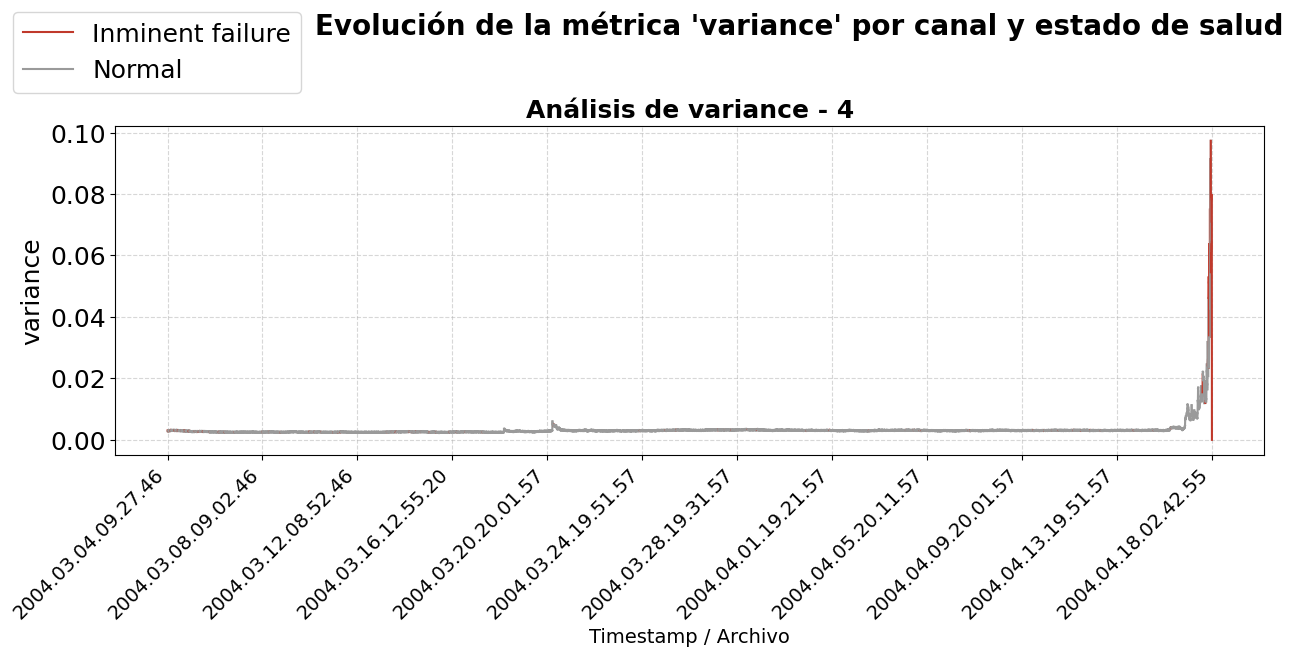

In [14]:
df_resultados = df.copy()

COLORES_ETIQUETA = {
    "Normal":                  "#9a9a9a",
    "Inminent failure":        "#c0392b",
}

#Repetir cada predicción de clase 8 veces seguidas para que coincida con el número de filas en df_resultados
predicted_classes_expanded = np.repeat(predicted_classes, 8)


df_resultados['predicted_class'] = predicted_classes_expanded

# Mapear los números 1 y 0 a textos descriptivos
mapeo_salud = {1: 'Normal', 0: 'Inminent failure'}
df_resultados['predicted_label'] = df_resultados['predicted_class'].map(
    mapeo_salud
)

mostrar_grafica_agrupada(df_resultados, 
                        metrica='variance', 
                        columna_salud='predicted_label', 
                        colores_salud=COLORES_ETIQUETA,
                        columna_canal='canal',
                        guardar_figura=True,
                        canal_a_mostrar=3,
                        nombre_figura="prediccion modelo MK-CNN - 3rd_test_normal+falla.png",
                        titulo_grafica="Evolución de la métrica 'variance' por canal y estado de salud")